# Credit Score Classification

Credit scores play a pivotal role in assessing an individual's creditworthiness and determining access to financial services. Existing credit scoring systems often lack transparency, leaving individuals and financial institutions with limited understanding of the key factors influencing scores. This project aims to bridge this gap by classifying individuals into clear credit score categories—Poor, Standard, and Good—while also providing insights into the primary drivers behind these classifications.

After clean up our dataset, we chose logistic regression as our baseline model. We then trained decision trees and XGBoost to classify the credit scores of our samples. 

The best models...

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
import re
import matplotlib.pyplot as plt
import numpy as np


Our dataset is from Kaggle https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data . There are 50,000 rows in each of two files, so totally
100,000 rows. There are 28 columns in the dataset. Each row contains a customer's identity, personal information and financial information. Since there are changes on financial information of each cutomer over the months, the credit scores for the same customer might be different in different month. But in our study, we were not considering the time-related effect on credit scores, so we treat each row as a distinct customer, as long as a row is not completely identical to another row in all properties and entries. 

We have twenty numerical and eight categorical variables in this dataset. Our target variable is a categorical variable called Credit_Score with three levels: Poor, Standard and Good. Since there are typos or formatting flaws in some entries, thed df.info() shown may not represent the correct data types for each column. There are some missing values in the dataset that we need to drop or replace. 

The detailed processings on these variables will be explained in later sections. 

 

In [32]:
#Read Dataset
df= pd.read_csv('dataset/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

/var/folders/n2/hbm_2n0n7k56fnqv2q9mgbkm0000gn/T/ipykernel_42091/1022397046.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('dataset/train.csv')


In [33]:
df.shape

(100000, 28)

In [34]:
df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1. Data Cleaning

In this section, we conducted data cleaning and employed feature engineering techniques. We droped duplicates and unneccesary columns. We also checked missing values in each column. We processed missing values seperately for numerical and categorical variables. More details are in the later sections. 

In [35]:
df_cleaned = df.copy()
df_cleaned.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Since each row represents a customer, to ensure same person does not appear in the dataset more than once, we dropped any duplicates in the dataset.

In [36]:
# Drop duplicates 
df_cleaned.drop_duplicates


<bound method DataFrame.drop_duplicates of             ID Customer_ID     Month           Name   Age          SSN  \
0       0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265   
1       0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265   
2       0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265   
3       0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265   
4       0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265   
...        ...         ...       ...            ...   ...          ...   
99995  0x25fe9  CUS_0x942c     April          Nicks    25  078-73-5990   
99996  0x25fea  CUS_0x942c       May          Nicks    25  078-73-5990   
99997  0x25feb  CUS_0x942c      June          Nicks    25  078-73-5990   
99998  0x25fec  CUS_0x942c      July          Nicks    25  078-73-5990   
99999  0x25fed  CUS_0x942c    August          Nicks    25  078-73-5990   

      Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Acco

We then drop the identity columns 'ID','Customer_ID', 'Name', 'SSN'. 'Month' represents the reporting month of the credit score. Since we are not interested in time series related analysis in this project, we dropped 'Month' and treated each row as a distinct data point.

In [37]:
# Drop the personal information as columns
drop_columns = ['ID','Customer_ID','Month','Name','SSN']
df_cleaned = df_cleaned.drop(drop_columns, axis = 1)
df_cleaned.shape


(100000, 23)

We then checked missing values in each column and calculated the percentage of data that are missing in each column. The number shown on the second column represents the percentages. 

In [38]:
# Check missing values
missing_values = df_cleaned.isna().sum()
missing_rate = missing_values / len(df_cleaned) * 100
missing_rate

Age                          0.000
Occupation                   0.000
Annual_Income                0.000
Monthly_Inhand_Salary       15.002
Num_Bank_Accounts            0.000
Num_Credit_Card              0.000
Interest_Rate                0.000
Num_of_Loan                  0.000
Type_of_Loan                11.408
Delay_from_due_date          0.000
Num_of_Delayed_Payment       7.002
Changed_Credit_Limit         0.000
Num_Credit_Inquiries         1.965
Credit_Mix                   0.000
Outstanding_Debt             0.000
Credit_Utilization_Ratio     0.000
Credit_History_Age           9.030
Payment_of_Min_Amount        0.000
Total_EMI_per_month          0.000
Amount_invested_monthly      4.479
Payment_Behaviour            0.000
Monthly_Balance              1.200
Credit_Score                 0.000
dtype: float64

### 1.1 Numerical Data

Based on the data description, it seems that some numerical variables have abnormal values which are far from the majority.
Due to the typos in some entries, some numerical variables were incorrectly assigned as object. For example, 'Age' and 'Annual_Income' are mistakenly assigned as object. We first correct the format of the column names and data type. Then we eliminate data that is not eligible based on common sense. For example, 'Age' should be always a positive number, so we dropped the rows with negative values in 'Age'. We also processed missing data in this section.

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [40]:
# The numeric columns: 8
numerical_columns = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate','Delay_from_due_date', 'Num_of_Loan', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries']

len(numerical_columns)

16

In [41]:
df_cleaned.select_dtypes('number').columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

We formatted column names by replace the spaces with underscores.

In [42]:
# format the columns
# replace spaces with underscores
df_cleaned['Age'] = df_cleaned['Age'].str.replace(r'_', '', regex=True).astype(int)
df_cleaned['Num_of_Loan'] = df_cleaned['Num_of_Loan'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Outstanding_Debt'] = df_cleaned['Outstanding_Debt'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Monthly_Balance'] = df_cleaned['Monthly_Balance'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Num_of_Delayed_Payment'] = df_cleaned['Num_of_Delayed_Payment'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Amount_invested_monthly'] = df_cleaned['Amount_invested_monthly'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Changed_Credit_Limit'] = df_cleaned['Changed_Credit_Limit'].str.replace(r'_', '', regex=True).replace('', np.nan).astype(float)

'Age', 'Num_Bank_Accounts','Num_of_Delayed_Payment' have to be greater or equal to 0, so we eliminated the data that violate this intuition. 'Credit_History_Age' was originally in text formatted withe format of "dd Years and d Months",so we converted into days. 

In [43]:
# Convert Data Types: Ensure numeric format
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Drop all rows of age less than 0
df_cleaned = df_cleaned[(df_cleaned['Age'] >= 0) & (df_cleaned['Age'] <= 100)]

# Drop all the num of loans less than 0
df_cleaned = df_cleaned[df_cleaned['Num_of_Loan']>=0]

# Reset all negative Num_Bank_Accounts to 0
df_cleaned.loc[df_cleaned['Num_Bank_Accounts']<0,'Num_Bank_Accounts'] = 0

# Reset all negative Num_of_Delayed_Payment to 0
df_cleaned.loc[df_cleaned['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment'] = 0

#Convert Credit_History_Age to a float number of days
def age2days(text, years=0, months=0):
    # Validate and handle empty or invalid input
    if not text or not isinstance(text, str):
        return 0  # Return 0 if text is empty or invalid
    
    days_in_year = 365.25
    days_in_month = 30.44

    years_match = re.search(r'(\d+)\s*Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+)\s*Months?', text, re.IGNORECASE)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return int((years * days_in_year) + (months * days_in_month))

df_cleaned['Credit_History_Age'] = df_cleaned['Credit_History_Age'].apply(age2days)

We could have dropped missing values directly, but since the missing values take up a relatively significant portion for some variables (For example, there are about 15 percent of values of 'Monthly_Inhand_Salary' are missing), dropping these rows may cause losing important information. We then decided to fill them with either medians or means.  We did not use mean values to fill out the missing values, because we already see from the data description that there are many extreme values in some variables and mean values could be affected by these extreme values. Thus, we decided to first to replace the missing values with the median of each variable. 

In [44]:
# Handle Missing Values: Impute with median
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    lambda x: x.fillna(x.median())
)

From the data description from the previous section, there are extreme values, so we ploted boxplots to check the distribution of these numerical variables. It turned out that for variables, such as 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_Of_Loan', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', data is significantly right skewed. Many data points are far from the majority. Thus, we decided to drop any outliers. We define outliers as any points lying on the bottom 1% or top 1% of the data for each column.

In [45]:
def plot_boxplots(df):
    """
    Plots a boxplot for each column in the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with columns to plot.
    """

    # Plot each column
    for column in numerical_columns:
        plt.figure(figsize=(4, 3))
        sns.boxplot(data=df, x=column, color='lightblue')
        plt.title(f'Boxplot for {column}', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

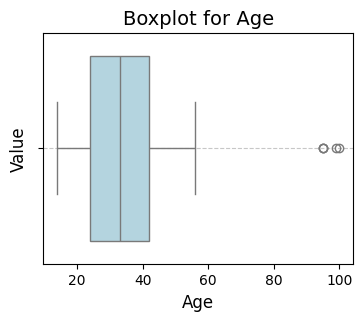

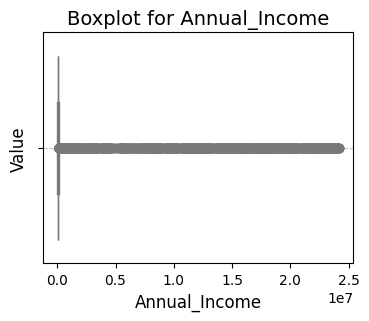

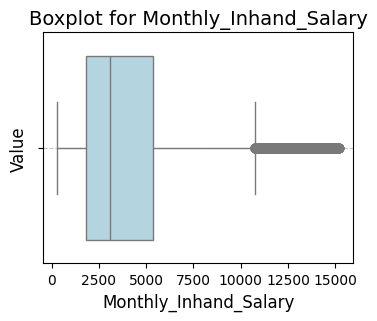

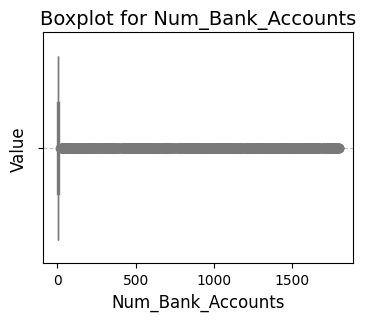

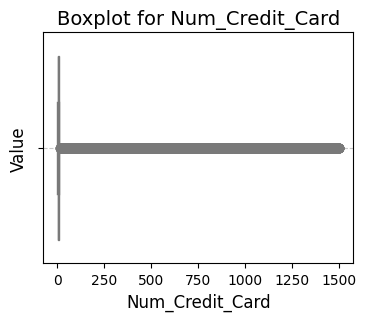

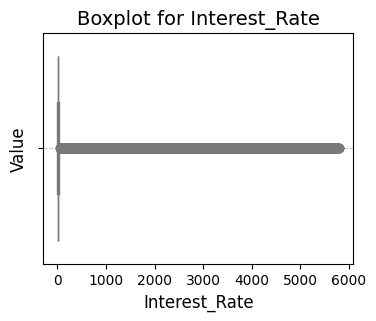

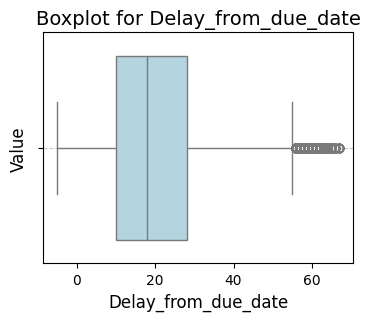

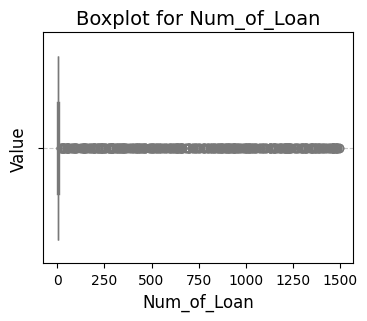

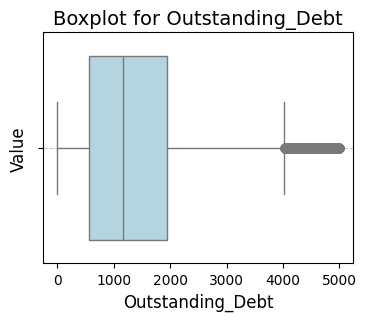

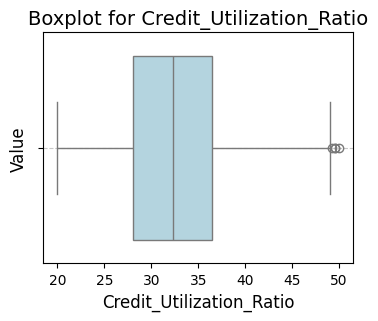

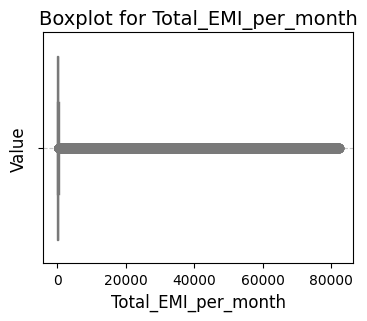

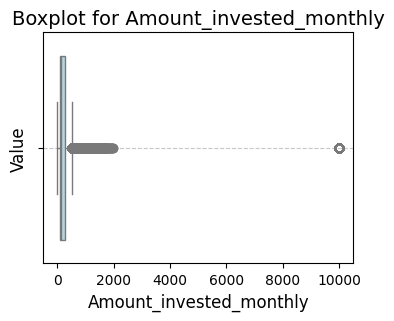

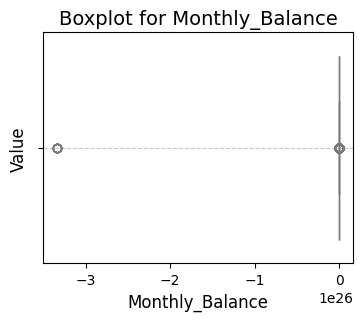

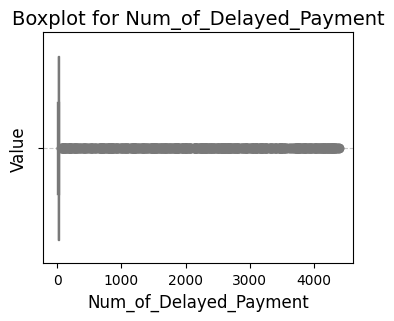

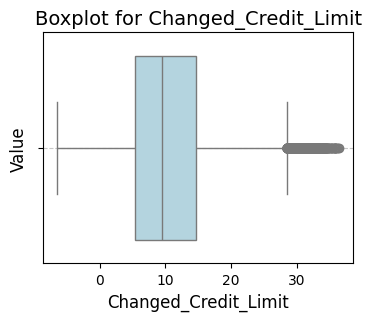

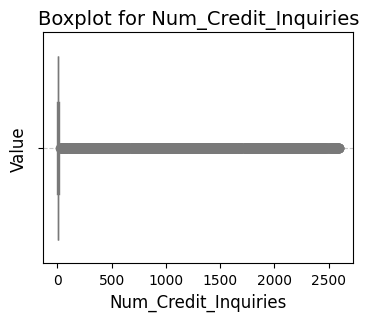

In [46]:
plot_boxplots(df_cleaned[numerical_columns])


In [49]:
def drop_outliers_boxplot(df):
    """
    Drops rows containing outliers based on the boxplot (IQR method) for all numerical columns.

    Parameters:
        df (pd.DataFrame): Input DataFrame.

    Returns:
        pd.DataFrame: DataFrame with outliers removed.
    """
    numerical_columns = df.select_dtypes(include=['number']).columns
    df_cleaned = df.copy()

    for column in numerical_columns:
        # Calculate Q1, Q3, and IQR
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define bounds for non-outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers
        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

    return df_cleaned


df_cleaned = drop_outliers_boxplot(df_cleaned)
df_cleaned.describe()



,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000,56143.000000
mean,33.323424,36599.825795,3053.096722,5.366920,5.479935,14.388259,3.425467,19.909250,13.358958,9.992692,5.730955,1269.945361,31.996598,6199.938389,75.534030,138.362689,358.659935
std,10.813031,23482.018177,1804.147736,2.504925,2.007703,8.520299,2.272814,13.145689,5.810595,6.082488,3.748376,893.630581,4.988135,3418.252726,69.652808,96.517095,123.137048
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,-6.440000,0.000000,0.230000,21.264254,0.000000,0.000000,0.000000,15.395195
25%,24.000000,17902.265000,1621.147500,4.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.520000,3.000000,560.520000,27.802657,3682.000000,25.147045,66.558628,274.939264
50%,33.000000,31318.220000,2950.711667,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.410000,6.000000,1150.280000,31.989481,6391.000000,53.721273,116.262421,332.722533
75%,42.000000,49140.870000,3635.250000,7.000000,7.000000,20.000000,5.000000,27.000000,18.000000,13.980000,8.000000,1765.825000,36.207520,8857.000000,105.305290,179.005617,421.543200
max,56.000000,145282.240000,10386.910000,11.000000,11.000000,34.000000,9.000000,57.000000,28.000000,28.850000,17.000000,3883.250000,43.884022,12296.000000,315.897041,464.979906,720.620605


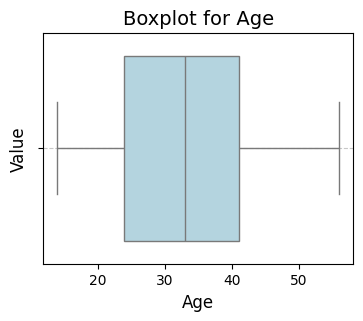

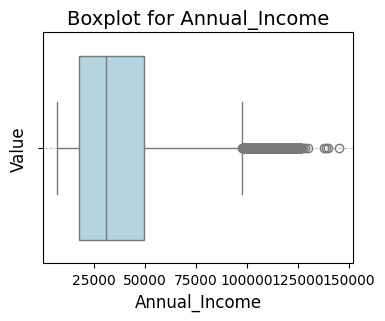

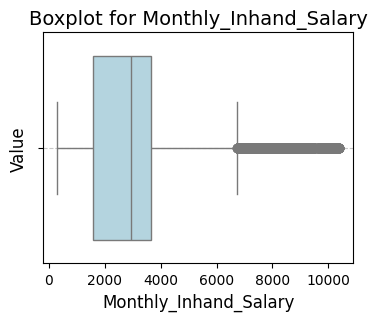

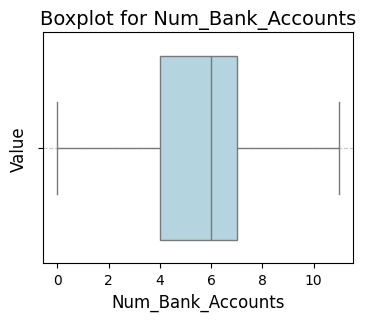

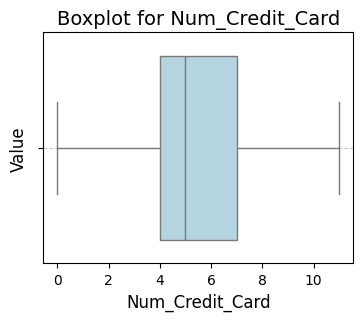

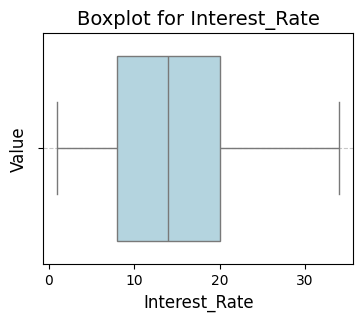

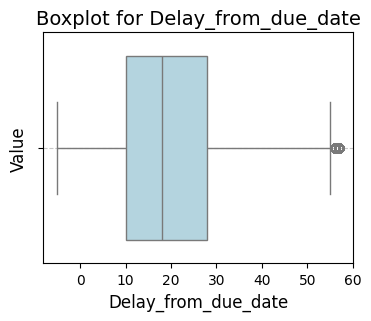

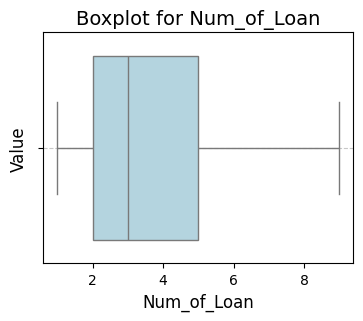

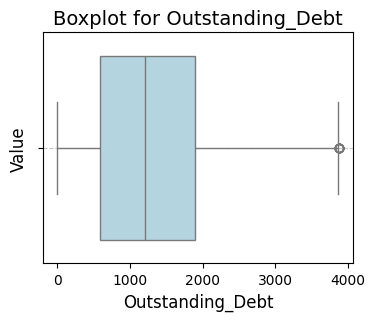

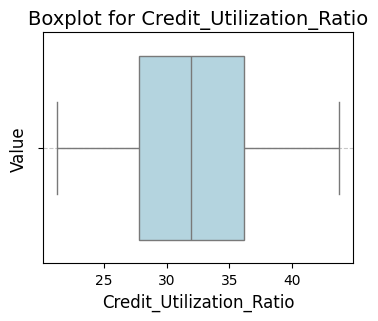

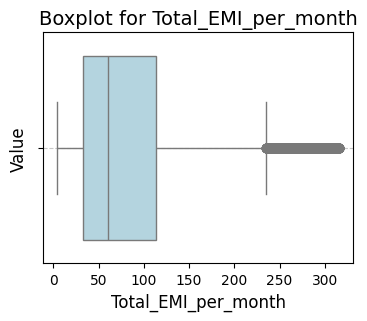

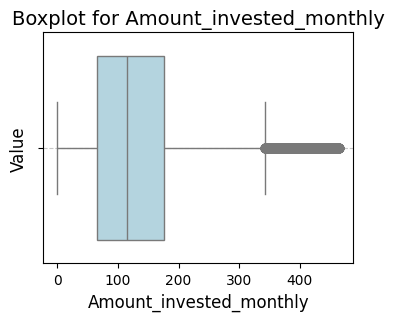

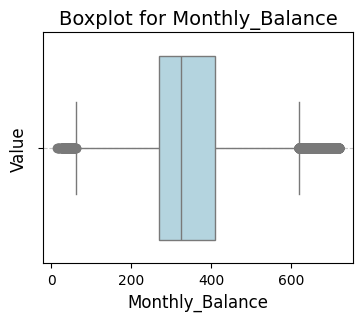

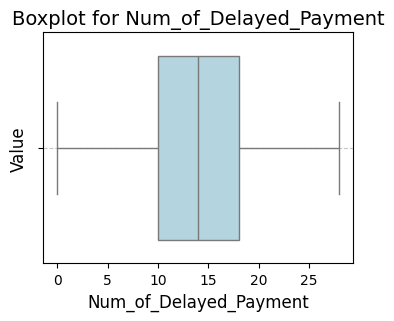

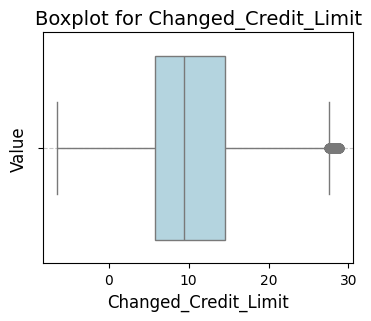

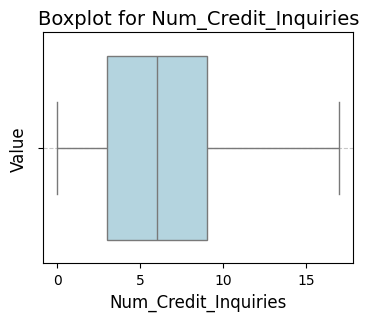

In [62]:
plot_boxplots(df_cleaned[numerical_columns])


In [18]:
# Remove Outliers: Clip to 1st and 99th percentile
for column in numerical_columns:
    lower = df_cleaned[column].quantile(0.01)
    upper = df_cleaned[column].quantile(0.99)
    df_cleaned[column] = df_cleaned[column].clip(lower, upper)

In [ ]:
df_cleaned.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000,78947.000000
mean,33.236576,47425.461488,3801.703021,5.529900,6.415861,16.789086,3.627725,21.409338,13.645686,10.495374,6.303811,1447.493672,32.151842,6057.782284,212.838853,187.549388,382.281698
std,10.761613,34335.046901,2625.098374,3.817215,13.327699,38.651809,2.468079,14.854143,6.085445,6.676425,10.864824,1162.179159,5.035806,3474.370518,1280.287852,186.049484,177.290538
min,14.000000,7534.185000,552.166250,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.504800,0.000000,27.630000,22.738761,0.000000,0.000000,17.157016,69.343298
25%,24.000000,19125.615000,1757.060000,4.000000,4.000000,8.000000,2.000000,10.000000,10.000000,5.550000,3.000000,575.920000,27.947329,3409.000000,29.865025,73.183215,270.202858
50%,33.000000,35891.330000,3095.905000,6.000000,5.000000,14.000000,3.000000,18.000000,14.000000,9.410000,6.000000,1185.950000,32.162994,6270.000000,66.377840,133.003315,336.381634
75%,42.000000,68484.440000,5115.943333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.930000,9.000000,1996.375000,36.377795,8796.000000,148.765699,222.698743,447.530458
max,55.000000,179948.840000,12823.446667,148.000000,317.000000,1037.000000,9.000000,61.000000,27.000000,28.810000,364.000000,4807.650000,42.445379,12296.000000,22911.000000,1878.503880,1015.495286


### 1.2 Categorical Data

In [50]:
# Handle Missing Values: drop missing values for categorical variables
df_cleaned = df_cleaned.dropna()

In [51]:
#Replace the '_______' value in the Occupation field with Other
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Other')

#Correct Typo
df_cleaned['Payment_of_Min_Amount'] = df_cleaned['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Drop Typo
df_cleaned = df_cleaned[df_cleaned['Payment_Behaviour']!='!@9#%8']

In [52]:
# hasn't done processing yet, drop for now

df_cleaned.drop(columns=['Type_of_Loan'],inplace=True)
df_cleaned.drop(columns=['Credit_Mix'],inplace=True)

## 2. Data Visualization

/var/folders/n2/hbm_2n0n7k56fnqv2q9mgbkm0000gn/T/ipykernel_42091/1147980377.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_cleaned['Credit_Score'],palette="mako")


(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000.]),
 [Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000'),
  Text(30000.0, 0, '30000')])

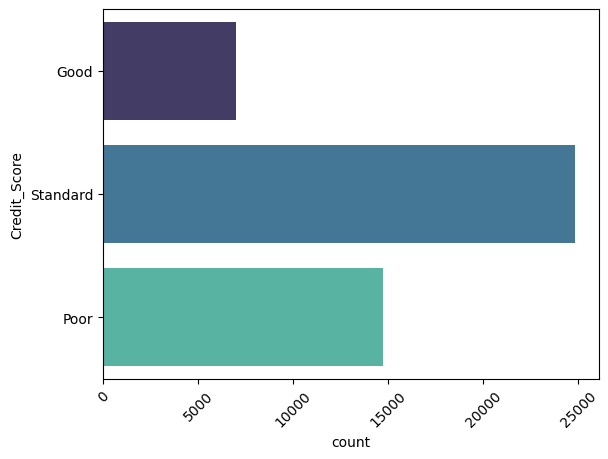

In [53]:
sns.countplot(df_cleaned['Credit_Score'],palette="mako")
plt.xticks(rotation=45)

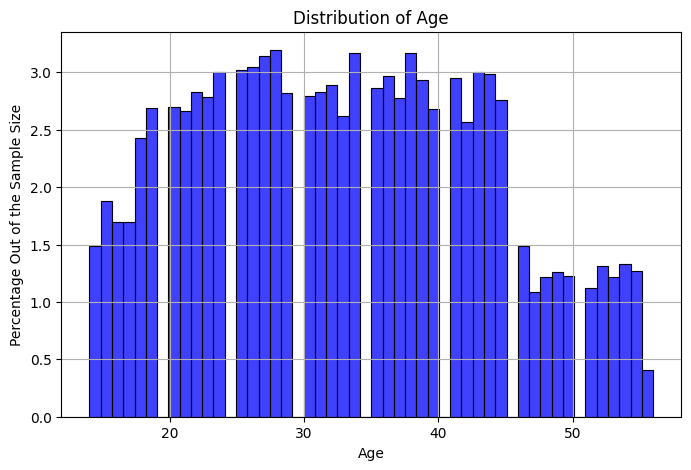

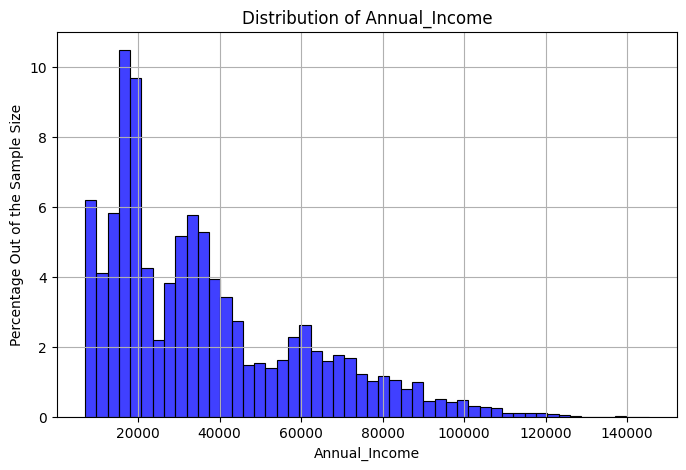

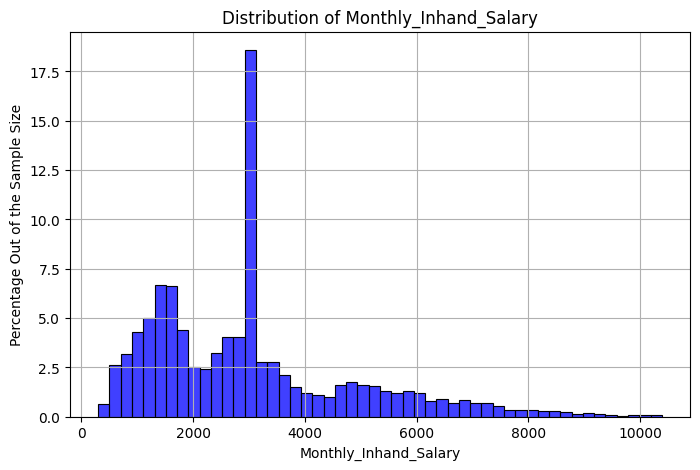

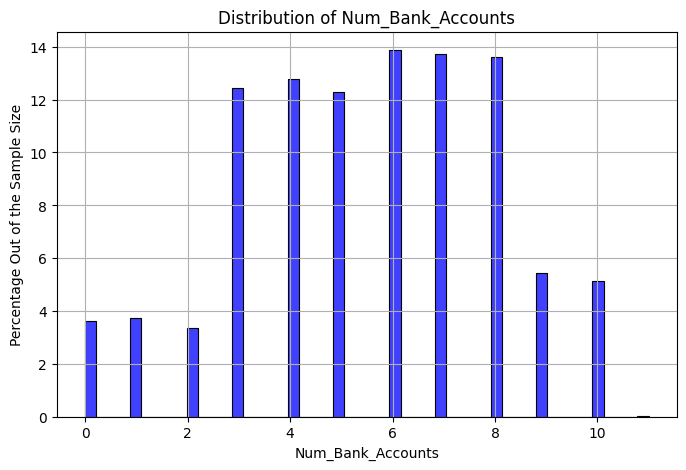

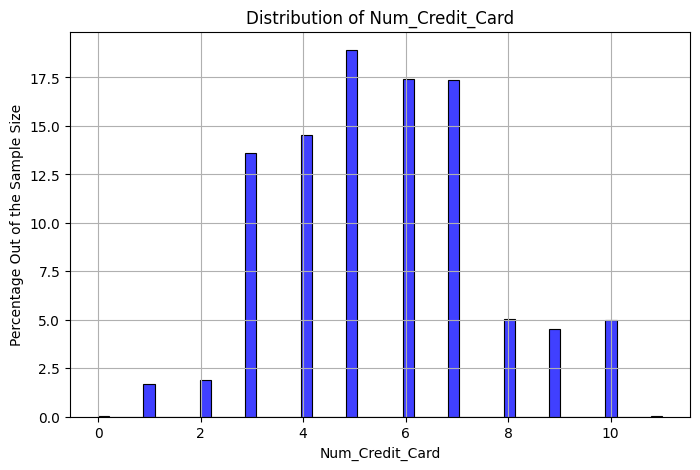

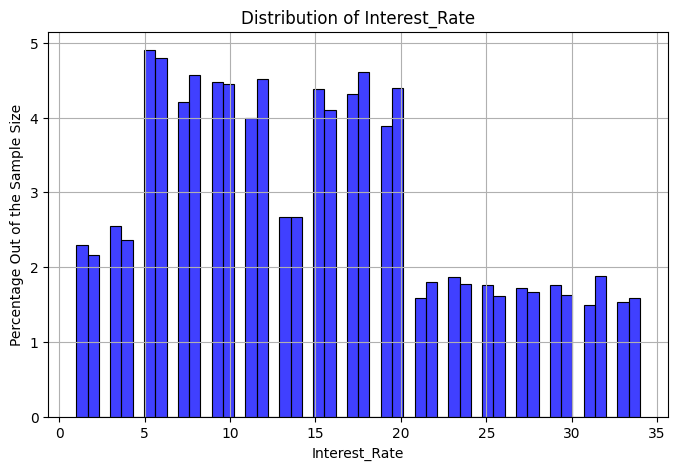

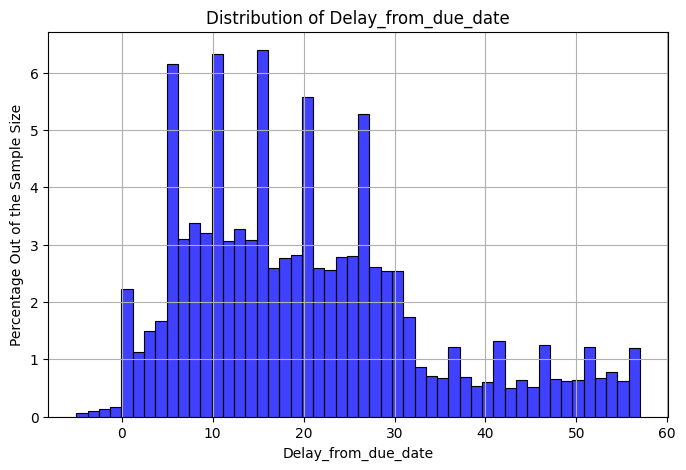

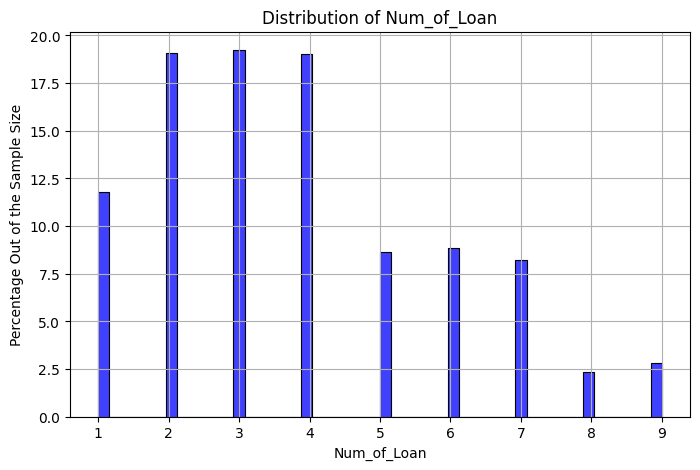

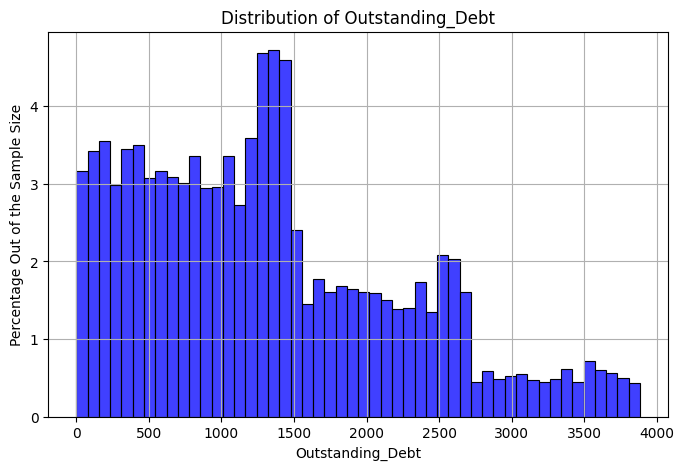

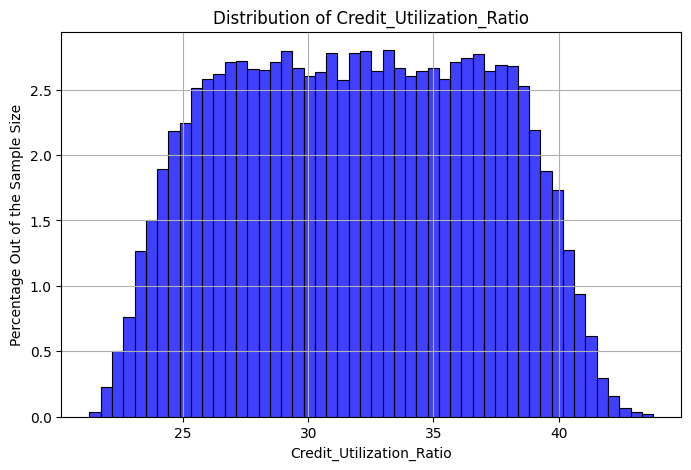

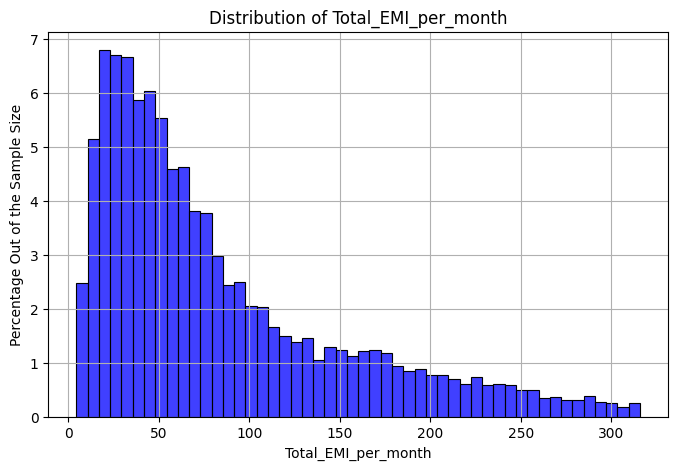

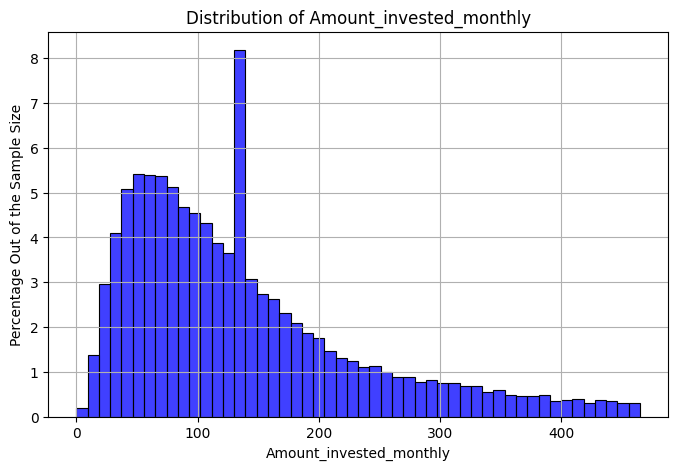

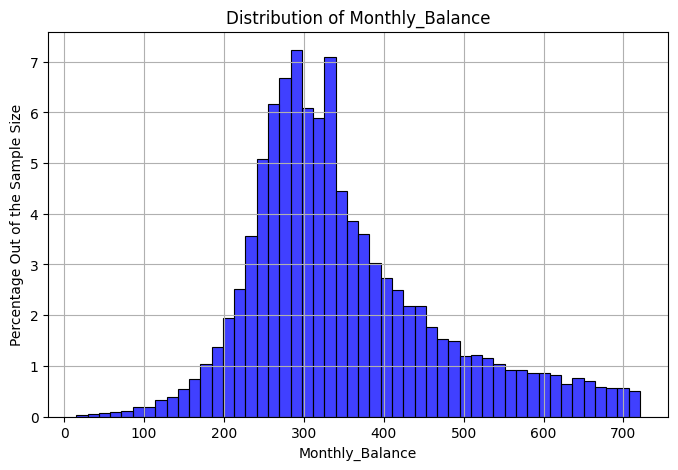

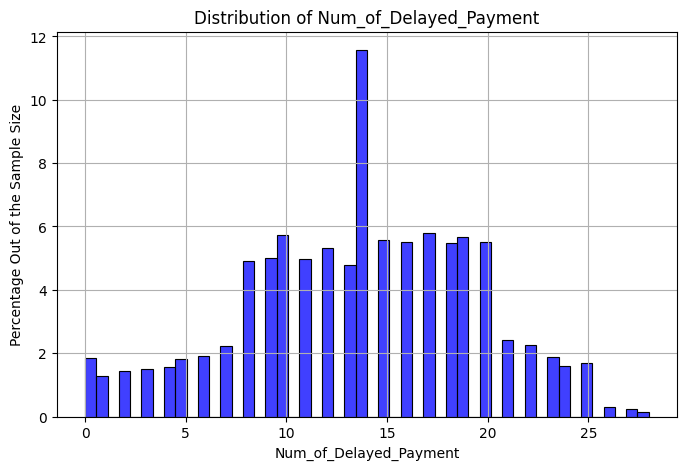

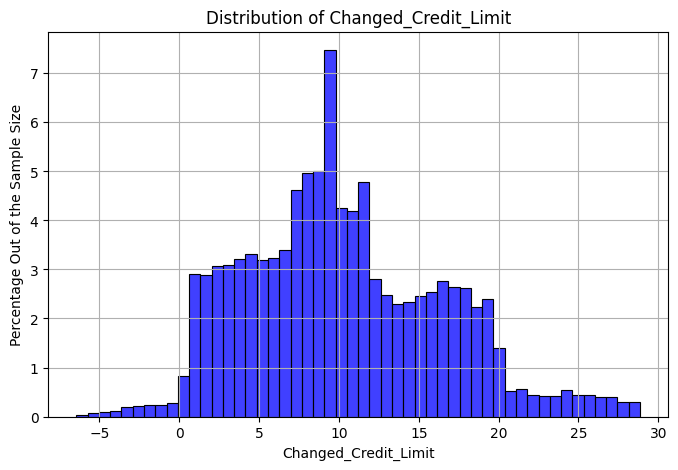

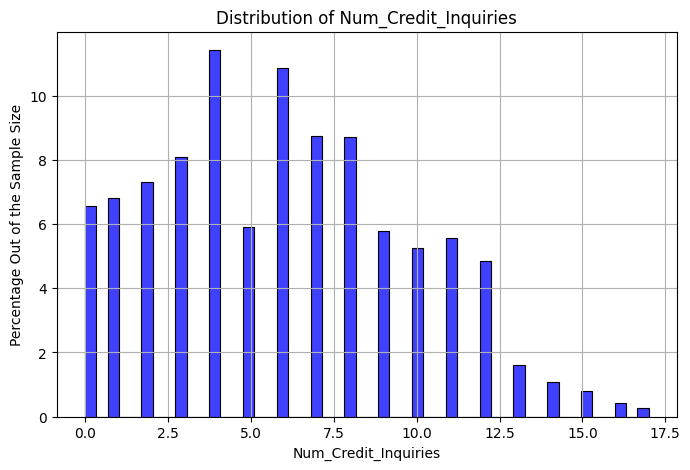

In [61]:
# Set up visualizations
for numerical_column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[numerical_column],
                 stat= 'percent', 
                 kde=False, 
                 bins=50, 
                 color='blue', 
                 edgecolor='black')
    plt.title(f'Distribution of {numerical_column}')
    plt.xlabel(numerical_column)
    plt.ylabel('Percentage Out of the Sample Size')
    plt.grid(True)
    plt.show()


## 3. Feature Engineering

### 3.1 Encoding

In [55]:
df_final = df_cleaned.copy()
df_final.head().T

,0,1,3,4,6
Age,23,23,23,23,23
Occupation,Scientist,Scientist,Scientist,Scientist,Scientist
Annual_Income,19114.12,19114.12,19114.12,19114.12,19114.12
Monthly_Inhand_Salary,1824.843333,3095.905,3095.905,1824.843333,1824.843333
Num_Bank_Accounts,3,3,3,3,3
Num_Credit_Card,4,4,4,4,4
Interest_Rate,3,3,3,3,3
Num_of_Loan,4.0,4.0,4.0,4.0,4.0
Delay_from_due_date,3,-1,5,6,3
Num_of_Delayed_Payment,7.0,14.0,4.0,14.0,8.0


In [56]:
df_final['Payment_of_Min_Amount'] = pd.get_dummies(df_final['Payment_of_Min_Amount'], columns=['Payment_of_Min_Amount'],prefix='Payment_of_Min_Amount',dtype=float,drop_first=True)

one_hot_encoding_columns = ['Occupation', 'Payment_Behaviour']
one_hot_encoded_columns = pd.get_dummies(df_final[one_hot_encoding_columns], dtype=float)
df_final = df_final.drop(columns=one_hot_encoding_columns).join(one_hot_encoded_columns)

In [57]:
X = df_final.drop(columns=['Credit_Score'])
X.head().T

,0,1,3,4,6
Age,23.000000,23.000000,23.000000,23.000000,23.000000
Annual_Income,19114.120000,19114.120000,19114.120000,19114.120000,19114.120000
Monthly_Inhand_Salary,1824.843333,3095.905000,3095.905000,1824.843333,1824.843333
Num_Bank_Accounts,3.000000,3.000000,3.000000,3.000000,3.000000
Num_Credit_Card,4.000000,4.000000,4.000000,4.000000,4.000000
Interest_Rate,3.000000,3.000000,3.000000,3.000000,3.000000
Num_of_Loan,4.000000,4.000000,4.000000,4.000000,4.000000
Delay_from_due_date,3.000000,-1.000000,5.000000,6.000000,3.000000
Num_of_Delayed_Payment,7.000000,14.000000,4.000000,14.000000,8.000000
Changed_Credit_Limit,11.270000,11.270000,6.270000,11.270000,11.270000


In [58]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df_final['Credit_Score'])
y

array([0, 0, 0, ..., 1, 1, 2])

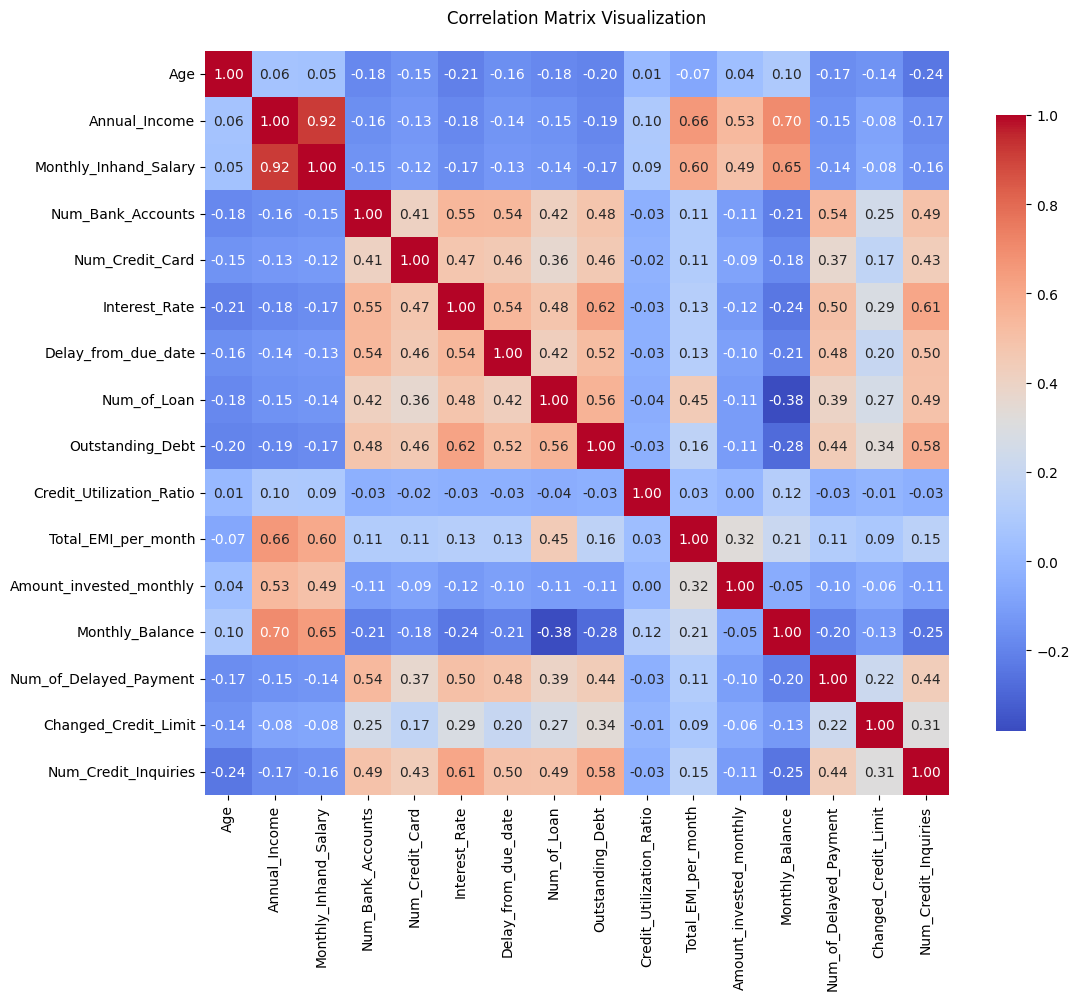

In [59]:
correlation_matrix = df_final[numerical_columns].corr() 

# Plotting the correlation matrix with exact coefficients
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Display the correlation coefficients
    fmt=".2f",           # Format the coefficients to 2 decimal places
    cmap='coolwarm',     # Colormap
    square=True,         # Make the heatmap squares
    cbar_kws={'shrink': 0.8}  # Colorbar settings
)

# Adding title and axis labels
plt.title("Correlation Matrix Visualization", pad=20)
plt.xticks(rotation=90)  # Rotate x-axis labels
plt.yticks(rotation=0)   # Keep y-axis labels horizontal
plt.show()

In [60]:
# Reduce dimensionality by dropping the variables to avoid multicolinearty
df_final = df_final.drop(['Monthly_Inhand_Salary'])

KeyError: "['Monthly_Inhand_Salary'] not found in axis"

## 4. Machine Learning

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(mse,acc)

0.7817154038482443 0.6171322969888031


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Accuracy: 0.69 0.6528970540276117
